In [ ]:
# pip install kagglehub[pandas-datasets]


   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---------------------------------------- 0/9 [urllib3]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- ----------------------------------- 1/9 [tqdm]
   ---- -----------------------

In [73]:
import pandas as pd
import kagglehub
import os


In [74]:
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Dataset downloaded to path:", path)

Dataset downloaded to path: C:\Users\lenovo\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1


In [75]:
files = os.listdir(path)
print("Files available:", files)

Files available: ['housing.csv']


In [76]:
csv_file = [f for f in files if f.endswith('.csv')][0] # Grabs the first CSV found
df = pd.read_csv(os.path.join(path, csv_file))
df.sample(7)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
15081,-116.94,32.81,22.0,4266.0,1010.0,2766.0,985.0,2.8175,135200.0,<1H OCEAN
5249,-118.45,34.08,52.0,1500.0,176.0,384.0,145.0,7.1576,500001.0,<1H OCEAN
3887,-118.53,34.21,18.0,3124.0,796.0,1855.0,725.0,2.9389,213200.0,<1H OCEAN
822,-122.06,37.63,23.0,1939.0,356.0,841.0,364.0,3.3611,169200.0,NEAR BAY
10686,-117.74,33.62,16.0,4134.0,740.0,2103.0,745.0,5.6877,231400.0,<1H OCEAN
1523,-122.08,37.90,32.0,1075.0,170.0,486.0,173.0,5.0499,306800.0,NEAR BAY
7808,-118.10,33.89,34.0,2242.0,436.0,1483.0,443.0,4.4934,185600.0,<1H OCEAN


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df.columns 

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

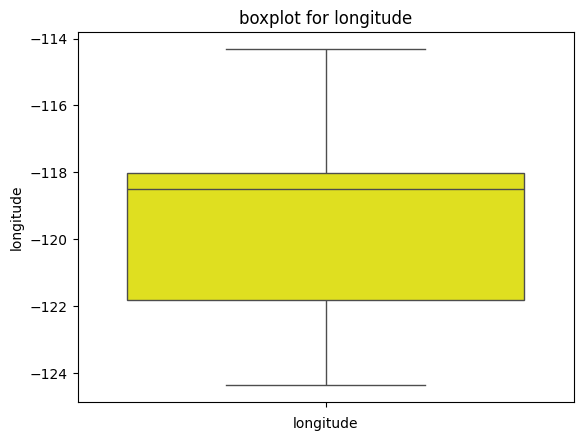

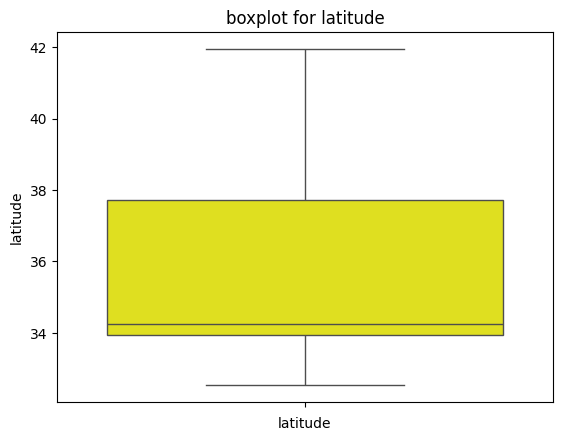

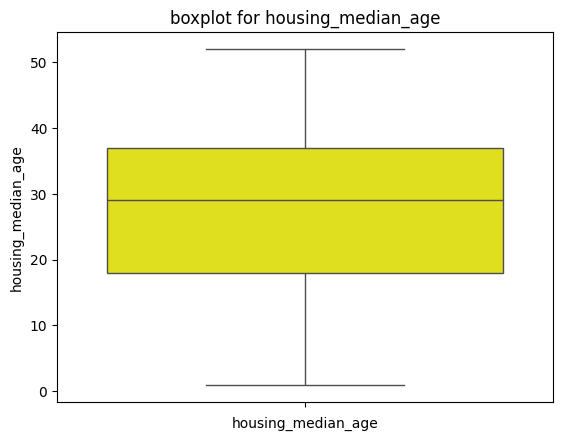

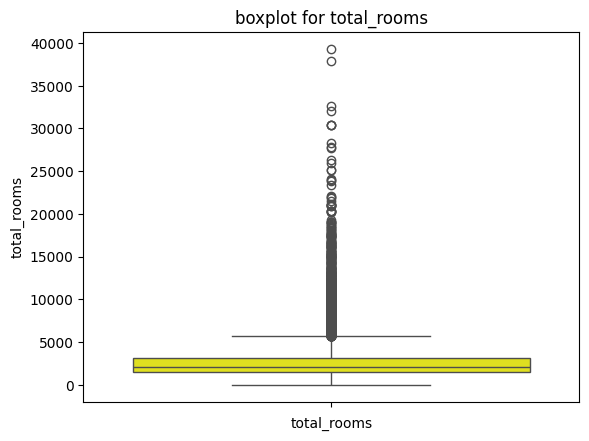

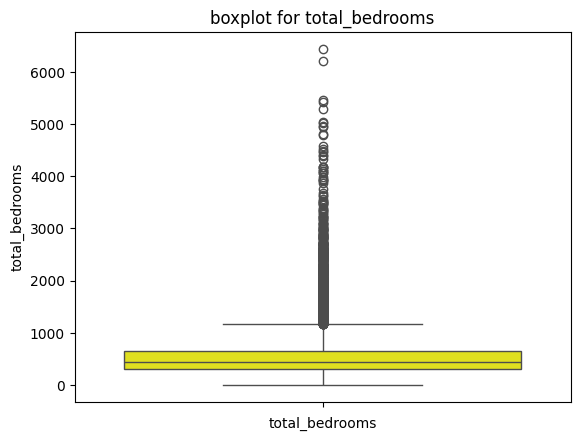

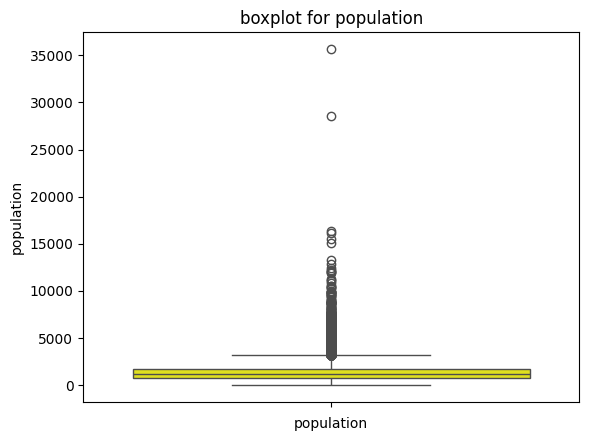

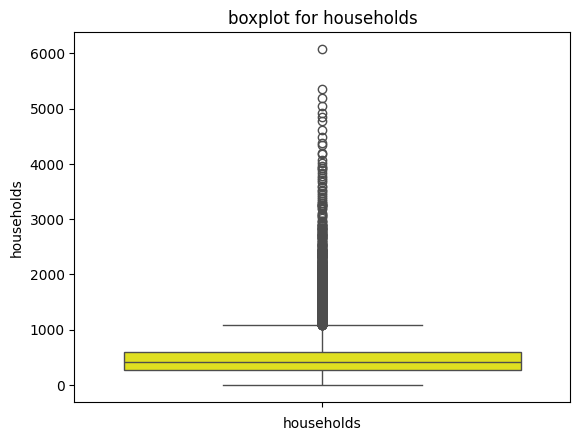

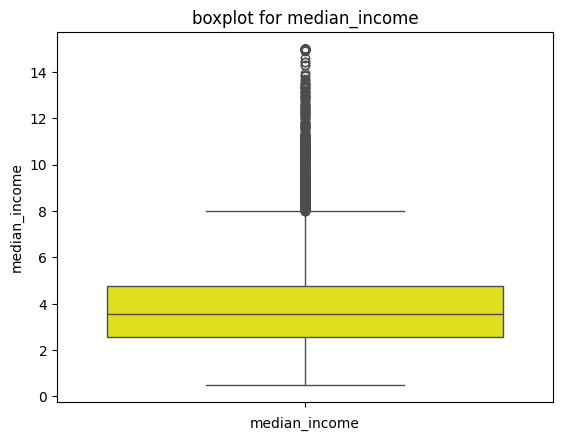

In [80]:
for col in df.columns:
    if ((df[col].dtype !='object') & (col !='median_house_value')):
        sns.boxplot(df[col],color='yellow')
        plt.xlabel(col)
        plt.title(f'boxplot for {col}')
        plt.show()


In [81]:
df_copy = df.copy()

q1 = df_copy.median_income.quantile(.25)
q3 = df_copy.median_income.quantile(.75)
iqr = q3-q1
ll = q1-iqr*1.5
ul = q3+iqr*1.5
df_copy = df_copy[((df_copy['median_income']>=ll) & (df_copy['median_income']<=ul))]

q1 = df_copy.population.quantile(.25)
q3 = df_copy.population.quantile(.75)
iqr = q3-q1
ll = q1-iqr*1.5
ul = q3+iqr*1.5
df_copy = df_copy[((df_copy['population']>=ll) & (df_copy['population']<=ul))]



q1 = df_copy.total_rooms.quantile(.25)
q3 = df_copy.total_rooms.quantile(.75)
iqr = q3-q1
ll = q1-iqr*1.5
ul = q3+iqr*1.5
df_copy = df_copy[((df_copy['total_rooms']>=ll) & (df_copy['total_rooms']<=ul))]


q1 = df_copy.total_bedrooms.quantile(.25)
q3 = df_copy.total_bedrooms.quantile(.75)
iqr = q3-q1
ll = q1-iqr*1.5
ul = q3+iqr*1.5
df_copy = df_copy[((df_copy['total_bedrooms']>=ll) & (df_copy['total_bedrooms']<=ul))]

q1 = df_copy.households.quantile(.25)
q3 = df_copy.households.quantile(.75)
iqr = q3-q1
ll = q1-iqr*1.5
ul = q3+iqr*1.5
df_copy = df_copy[((df_copy['households']>=ll) & (df_copy['households']<=ul))]

In [82]:
df_copy.shape

(17484, 10)

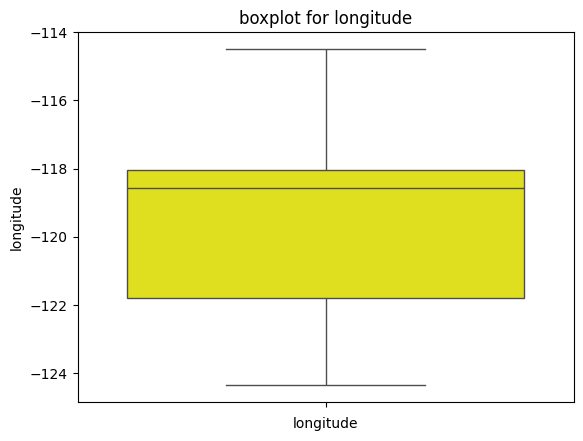

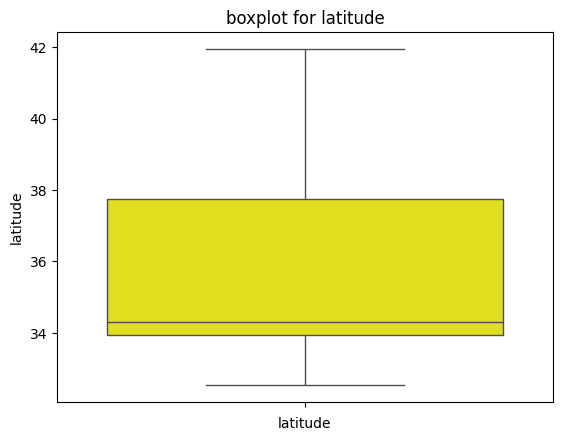

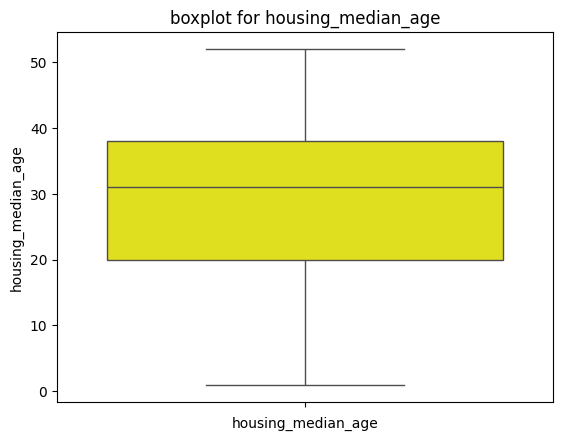

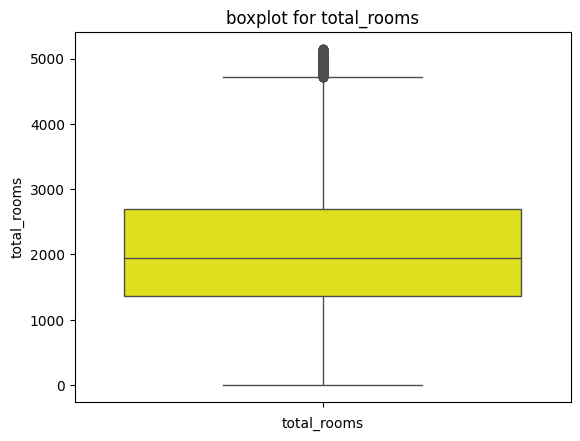

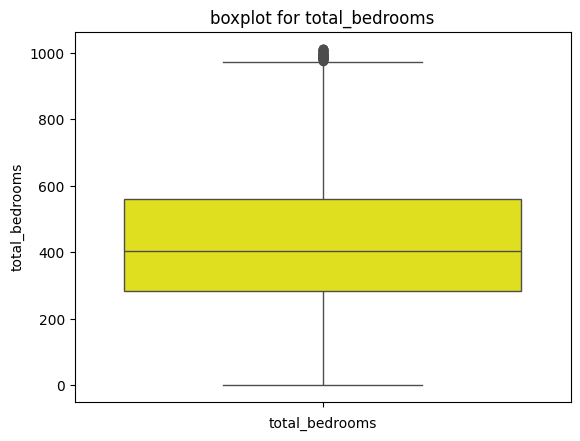

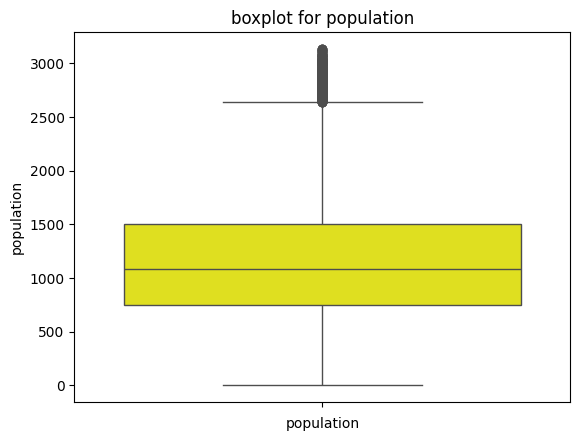

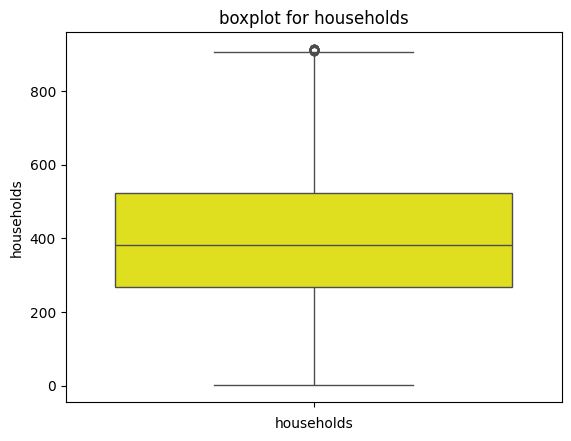

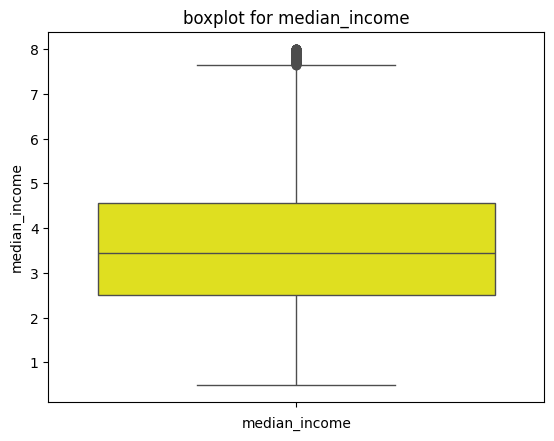

In [83]:
for col in df_copy.columns:
    if ((df_copy[col].dtype !='object') & (col !='median_house_value')):
        sns.boxplot(df_copy[col],color='yellow')
        plt.xlabel(col)
        plt.title(f'boxplot for {col}')
        plt.show()


In [84]:
df_copy.ocean_proximity.unique()
df_copy.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [93]:
from sklearn.preprocessing import LabelEncoder
lencode = LabelEncoder()

for col in df_copy.columns:
    if df_copy[col].dtype =='object':
        df_copy[col] = lencode.fit_transform(df_copy[col])

df_copy.sample(7)
df_copy.info()


<class 'pandas.core.frame.DataFrame'>
Index: 17484 entries, 2 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17484 non-null  float64
 1   latitude            17484 non-null  float64
 2   housing_median_age  17484 non-null  float64
 3   total_rooms         17484 non-null  float64
 4   total_bedrooms      17484 non-null  float64
 5   population          17484 non-null  float64
 6   households          17484 non-null  float64
 7   median_income       17484 non-null  float64
 8   median_house_value  17484 non-null  float64
 9   ocean_proximity     17484 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.5 MB


In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for col in df_copy.columns:
    if ((df_copy[col].dtype !='object') & (col !="median_house_value")):
        vif.append(col)

vif_table = pd.DataFrame()
x = df_copy[vif]
vif_table['feature'] = vif
vif_table['score'] = [variance_inflation_factor(x.values,i) for i in range(0,len(x.columns))]
vif_table

e:\code\datascience\plot\.venv\ml\ML_Prog\.venv\lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,feature,score
0,longitude,687.601050
1,latitude,583.331061
2,housing_median_age,7.841153
3,total_rooms,46.890204
4,total_bedrooms,125.489592
5,population,19.860232
6,households,124.984739
7,median_income,14.094398
8,ocean_proximity,NaN


In [96]:
len(x.columns)

9

In [99]:
from statsmodels.tools.tools import add_constant

In [100]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 1. Filter out object columns, target column, and handle potential missing values
vif_cols = []
for col in df_copy.columns:
    if (df_copy[col].dtype != 'object') and (col != "median_house_value"):
        # Extra safety check: Drop features with zero variance (all identical values) 
        if df_copy[col].nunique() > 1:
            vif_cols.append(col)

# Extract features and drop any missing values to prevent linear algebra failure
x = df_copy[vif_cols].dropna()

# 2. CRITICAL FIX: Add a constant intercept column to prevent NaN/inf errors
x_with_const = add_constant(x)

# 3. Calculate VIF using the matrix that includes the intercept
vif_table = pd.DataFrame()
vif_table['feature'] = vif_cols

# The list comprehension loops through indices matching your original feature positions
vif_table['score'] = [
    variance_inflation_factor(x_with_const.values, x_with_const.columns.get_loc(col)) 
    for col in vif_cols
]

vif_table


,feature,score
0,longitude,9.050161
1,latitude,9.555091
2,housing_median_age,1.202930
3,total_rooms,9.444207
4,total_bedrooms,22.732871
5,population,3.917960
6,households,23.338135
7,median_income,2.256567
